# Prithvi-WxC Inference Verification

This notebook verifies the inference setup for Prithvi-WxC TC forecasts.

In [2]:
!pip uninstall -y pytorch_retrieve
!pip install git+https://github.com/simonpf/pytorch_retrieve

Found existing installation: pytorch_retrieve 0.1.6.dev1+g137f75ffb
Uninstalling pytorch_retrieve-0.1.6.dev1+g137f75ffb:
  Successfully uninstalled pytorch_retrieve-0.1.6.dev1+g137f75ffb
  Cloning https://github.com/simonpf/pytorch_retrieve to /tmp/pip-req-build-nldw_ywl
  Running command git clone --filter=blob:none --quiet https://github.com/simonpf/pytorch_retrieve /tmp/pip-req-build-nldw_ywl
  Resolved https://github.com/simonpf/pytorch_retrieve to commit 137f75ffb4215713d7bbb8fe78bb7a787b5dfad3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pytorch_retrieve: filename=pytorch_retrieve-0.1.6.dev1+g137f75ffb-py3-none-any.whl size=203881 sha256=0258ca08f70b2c50491ed8f292f1972b07112824e90f2aa4f01075efc0a00a3d
  Stored in directory: /tmp/pip-ephem-wheel-cache-4q4jmfk6/wheels/af/7b/96/fcc2b2c799a67afbaa97d58fef064e2f1b8438c25ba303ab84
Successfully built pytorch_retrieve


In [3]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

## Prithvi-WxC Setup

Below we set up the data loader and model similar to the [rollout example](https://github.com/NASA-IMPACT/Prithvi-WxC/blob/main/examples/PrithviWxC_rollout.ipynb) from the Prithvi-WxC repository.

### Dataset

In [4]:
from PrithviWxC.configs import get_model_config
from PrithviWxC.dataloaders.merra2_rollout import Merra2RolloutDataset

config_name = "large_rollout"
prithvi_config = get_model_config(config_name, data_dir="../../data")

input_data_path = Path("/mnt/ssd-data2/TEMP/data/prithvi_inputs/2021/")
climatology_path = Path("/mnt/ssd-data2/TEMP/hf_cache/climatology/")

dataset = Merra2RolloutDataset(
    time_range=("2021-08-27T18:00:00", "2021-08-30"),
    lead_time=12,
    input_time=-6,
    data_path_surface=input_data_path,
    data_path_vertical=input_data_path,
    climatology_path_surface=climatology_path,
    climatology_path_vertical=climatology_path,
    surface_vars=prithvi_config.surface_vars,
    static_surface_vars=prithvi_config.static_surface_vars,
    vertical_vars=prithvi_config.vertical_vars,
    levels=prithvi_config.levels,
    positional_encoding="fourier",
)
assert 0 < len(dataset), "There doesn't seem to be any valid data."

### Model

In [5]:
from PrithviWxC.dataloaders.merra2 import (
    input_scalers,
    output_scalers,
    static_input_scalers,
)

surf_in_scal_path = climatology_path / "musigma_surface.nc"
vert_in_scal_path = climatology_path / "musigma_vertical.nc"
surf_out_scal_path = climatology_path / "anomaly_variance_surface.nc"
vert_out_scal_path = climatology_path / "anomaly_variance_vertical.nc"


in_mu, in_sig = input_scalers(
    prithvi_config.surface_vars,
    prithvi_config.vertical_vars,
    prithvi_config.levels,
    surf_in_scal_path,
    vert_in_scal_path,
)

output_sig = output_scalers(
    prithvi_config.surface_vars,
    prithvi_config.vertical_vars,
    prithvi_config.levels,
    surf_out_scal_path,
    vert_out_scal_path,
)

static_mu, static_sig = static_input_scalers(
    surf_in_scal_path,
    prithvi_config.static_surface_vars,
)

### Model init
We can now build and load the pretrained weights, note that you should use the
rollout version of the weights.

In [6]:
import torch
import yaml
from PrithviWxC.model import PrithviWxC

weights_path = Path("/mnt/ssd-data1/prithvi_tc/prithvi.wxc.rollout.2300m.v1.pt")
device = "cuda:1"

model = PrithviWxC(
    in_channels=prithvi_config.in_channels,
    input_size_time=prithvi_config.input_size_time,
    in_channels_static=prithvi_config.in_channels_static,
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=prithvi_config.input_scalers_epsilon,
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=prithvi_config.static_input_scalers_epsilon,
    output_scalers=output_sig**0.5,
    n_lats_px=prithvi_config.n_lats_px,
    n_lons_px=prithvi_config.n_lons_px,
    patch_size_px=prithvi_config.patch_size_px,
    mask_unit_size_px=prithvi_config.mask_unit_size_px,
    mask_ratio_inputs=0.0,
    mask_ratio_targets=0.0,
    embed_dim=prithvi_config.embed_dim,
    n_blocks_encoder=prithvi_config.n_blocks_encoder,
    n_blocks_decoder=prithvi_config.n_blocks_decoder,
    mlp_multiplier=prithvi_config.mlp_multiplier,
    n_heads=prithvi_config.n_heads,
    dropout=prithvi_config.dropout,
    drop_path=prithvi_config.drop_path,
    parameter_dropout=prithvi_config.parameter_dropout,
    residual=prithvi_config.residual,
    masking_mode=prithvi_config.masking_mode,
    encoder_shifting=True,
    decoder_shifting=prithvi_config.decoder_shifting,
    positional_encoding="fourier",
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)

state_dict = torch.load(weights_path, weights_only=False)
if "model_state" in state_dict:
    state_dict = state_dict["model_state"]
model.load_state_dict(state_dict, strict=True)

if (hasattr(model, "device") and model.device != device) or not hasattr(
    model, "device"
):
    model = model.to(device)

Run reference forecasts. We run two of them to get an estimate of random errors in the forecast.

In [7]:
from PrithviWxC.dataloaders.merra2_rollout import preproc
from PrithviWxC.rollout import rollout_iter

padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}
rng_state_1 = torch.get_rng_state()
data = next(iter(dataset))
batch = preproc([data], padding)
padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)
        
torch.manual_seed(42)
with torch.no_grad():
    model.eval()
    out = rollout_iter(dataset.nsteps, model.to(device="cuda:1"), batch)
    
slp_ref = out[0, prithvi_config.surface_vars.index("SLP")].cpu().numpy()

In [8]:
data = next(iter(dataset))
batch = preproc([data], padding)
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)
        
torch.manual_seed(42)
with torch.no_grad():
    model.eval()
    out = rollout_iter(dataset.nsteps, model.to(device="cuda:1"), batch)
    
slp_ref_2 = out[0, prithvi_config.surface_vars.index("SLP")].cpu().numpy()

## Prithvi Precip Inference

Now we set up the same inference using the Prithvi Precip framework. The input data for this is located in /mnt/ssd-data1/prithvi_tc/input_data

In [9]:
from pathlib import Path
from prithvi_precip.forecast.data_loaders import AutoregressiveForecastLoader
from torch.utils.data import DataLoader

input_data_path = Path("/mnt/ssd-data1/prithvi_tc/input_data/")

# Adapt this to run forecast for longer time range.
init_times = np.arange(
    np.datetime64("2021-08-28T00:00:00"),
    np.datetime64("2021-08-28T00:01:00"),
    np.timedelta64(6, "h")
)

data_loader = AutoregressiveForecastLoader(
    input_data_path,
    init_times=init_times,
    n_steps=2, # Number of 6-hour forecast steps.
    input_time=6, # Input data time step
    center_meridionally=False,
    full_climatology=True,
)
print(f"Found input data for {len(data_loader)} forecasts.")

Found input data for 1 forecasts.


In [10]:
%env PRITHVI_DATA_PATH=/mnt/ssd-data1/prithvi_tc/climatology

env: PRITHVI_DATA_PATH=/mnt/ssd-data1/prithvi_tc/climatology


In [11]:
from pytorch_retrieve.architectures import load_and_compile_model
from pytorch_retrieve.training import load_weights

mdl = load_and_compile_model("model.toml")
model_weights = Path("/mnt/ssd-data1/prithvi_tc/prithvi.wxc.rollout.2300m.v1.pt")

load_weights(
    {"backbone": model_weights},
    mdl
)

[18:04:44] INFO     Loading weights for 'backbone' from                                              ]8;id=778129;file:///home/simonpf/miniconda3/envs/prithvi_tc/lib/python3.12/site-packages/pytorch_retrieve/training.py\training.py]8;;\:]8;id=485498;file:///home/simonpf/miniconda3/envs/prithvi_tc/lib/python3.12/site-packages/pytorch_retrieve/training.py#65\65]8;;\
                    '/mnt/ssd-data1/prithvi_tc/prithvi.wxc.rollout.2300m.v1.pt'.                                   

In [1]:
import torch
from typing import Dict

def post_process_results(
    inpt: Dict[str, torch.Tensor],
    results: Dict[str, torch.Tensor],
    init_times: np.ndarray,
    valid_times: np.ndarray,
) -> xr.Dataset:
    """
    Extracts surface winds, surface pressure and 850 winds from forecast results.

    Args:
        inpt: The batch containing the input data.
        results: A dictionary containing the forecast results.

    Return:
        An xarray.Dataset containing the results to be stored.
    """
    static = inpt["static"]
    if static.dim() == 5:
        lats = np.rad2deg(inpt["static"][0, 0, 0, :, 0].float().cpu().numpy())
        lons = np.rad2deg(inpt["static"][0, 0, 1, 0, :].float().cpu().numpy())
    else:
        lats = np.rad2deg(inpt["static"][0, 0, :, 0].float().cpu().numpy())
        lons = np.rad2deg(inpt["static"][0, 1, 0, :].float().cpu().numpy())

    var_inds = [9, 17, 18, -18, -4]

    # Stack output steps into single array
    pred = np.stack([step[:, [9, 17, 18, -18, -4]].float().cpu().numpy() for step in results["y"]], axis=1)
    # Add analysis to forecast results
    analysis = inpt["x"][:, 1:, var_inds].float().cpu().numpy()
    pred = np.concatenate((analysis, pred), 1)
    valid_times = np.concatenate([init_times.reshape((init_times.shape[0], 1)), valid_times], 1)
    
    dataset = xr.Dataset({
        "initialization_time": (("batch",), init_times),
        "valid_time": (("batch", "step",), valid_times),
        "latitude": (("latitude",), lats),
        "longitude": (("longitude",), lons)
    })
    
    slp = pred[:, :, 0]
    u10 = pred[:, :, 1]
    v10 = pred[:, :, 2]
    u850 = pred[:, :, 3]
    v850 = pred[:, :, 4]

    dataset["slp"] = (("batch", "step", "latitude", "longitude"), slp)
    dataset["u10"] = (("batch", "step", "latitude", "longitude"), u10)
    dataset["v10"] = (("batch", "step", "latitude", "longitude"), v10)
    dataset["u850"] = (("batch", "step", "latitude", "longitude"), u850)
    dataset["v850"] = (("batch", "step", "latitude", "longitude"), v850)

    for var in ["slp", "u10", "v10", "u850", "v850"]:
        dataset[var].encoding = {"dtype": "float32", "zlib": True}

    return dataset


NameError: name 'np' is not defined

In [29]:
from prithvi_precip.forecast.runners import run_autoregressive_forecast

output_path = Path("/mnt/ssd-data1/prithvi_tc/results")
output_path.mkdir(exist_ok=True)
torch.manual_seed(42)
run_autoregressive_forecast(
    mdl,
    data_loader,
    output_path,
    post_process_fn=post_process_results,
    device=device,
    dtype=torch.float32,
)
results = xr.load_dataset(output_path / "forecast_202108280000.nc")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:30<00:00, 30.74s/it]


## Results 

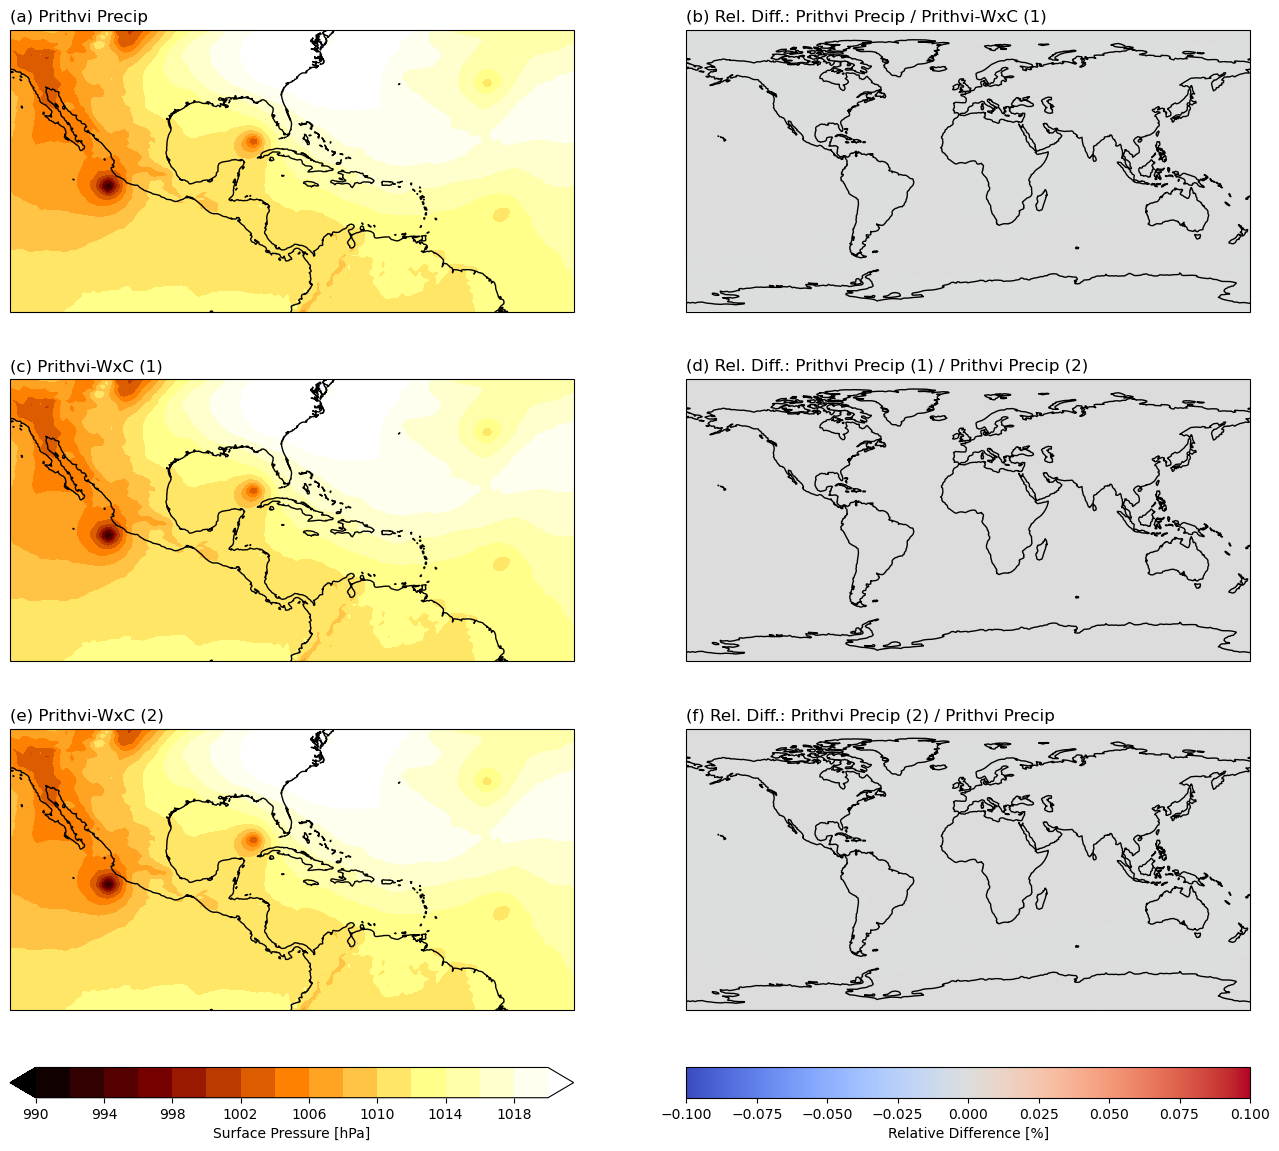

In [33]:
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(4, 2, width_ratios=[1.0, 1.0], height_ratios=[1.0, 1.0, 1.0, 0.1])
crs = ccrs.PlateCarree()

lons = results.longitude.data
lats = results.latitude.data
slp = results.slp.data[2]

valid_time = results.valid_time.data[2]

levels = np.linspace(990, 1020, 16)

ax = fig.add_subplot(gs[0, 0], projection=crs)
m = ax.contourf(lons, lats, slp / 100, vmin=990, vmax=1020, levels=levels, extend="both", cmap="afmhot")
ax.set_xlim(-120, -40)
ax.set_ylim(0, 40)
ax.set_title("(a) Prithvi Precip", loc="left")
ax.coastlines()

ax = fig.add_subplot(gs[0, 1], projection=crs)
diff = 100 * (slp - slp_ref) / slp_ref
plt.pcolormesh(lons, lats, diff, vmin=-0.1, vmax=0.1, cmap="coolwarm")
ax.set_title("(b) Rel. Diff.: Prithvi Precip / Prithvi-WxC (1)", loc="left")
ax.coastlines()

ax = fig.add_subplot(gs[1, 0], projection=crs)
m = ax.contourf(lons, lats, slp_ref / 100, vmin=990, vmax=1020, levels=levels, extend="both", cmap="afmhot")
ax.set_title("(c) Prithvi-WxC (1)", loc="left")
ax.set_xlim(-120, -40)
ax.set_ylim(0, 40)
ax.coastlines()

ax = fig.add_subplot(gs[1, 1], projection=crs)
diff = 100 * (slp_ref - slp_ref_2) / slp_ref_2
ax.set_title("(d) Rel. Diff.: Prithvi Precip (1) / Prithvi Precip (2)", loc="left")
plt.pcolormesh(lons, lats, diff, vmin=-0.1, vmax=0.1, cmap="coolwarm")
ax.coastlines()

ax = fig.add_subplot(gs[2, 0], projection=crs)
m_slp = ax.contourf(lons, lats, slp_ref_2 / 100, vmin=990, vmax=1020, levels=levels, extend="both", cmap="afmhot")
ax.set_title("(e) Prithvi-WxC (2)", loc="left")
ax.set_xlim(-120, -40)
ax.set_ylim(0, 40)
ax.coastlines()

ax = fig.add_subplot(gs[2, 1], projection=crs)
diff = 100 * (slp_ref_2 - slp) / slp
ax.set_title("(f) Rel. Diff.: Prithvi Precip (2) / Prithvi Precip", loc="left")
m_diff = plt.pcolormesh(lons, lats, diff, vmin=-0.1, vmax=0.1, cmap="coolwarm")
ax.coastlines()

cax = fig.add_subplot(gs[-1, 0])
plt.colorbar(m_slp, label="Surface Pressure [hPa]", orientation="horizontal", cax=cax)

cax = fig.add_subplot(gs[-1, 1])
plt.colorbar(m_diff, label="Relative Difference [%]", orientation="horizontal", cax=cax)